# The D-optimality ceiling, and what the method captures

Two questions, for two devices:

- **How much can shot allocation be worth, at most**, with the total number of shots fixed?
- **How much of that does the adaptive method actually get?**

Both are answered **entirely in information space** -- no GST fits, no sampled data, no
conversion to an error metric. That restriction is the point: it is what makes the comparison
airtight.

The two devices are the same gate set with different truth models:

| device | `Gxpi2` true infidelity | the others |
|---|---|---|
| **baseline** | 4.6e-03 | 4.4e-03 to 6.5e-03 |
| **clean-X** | **6.9e-05** | unchanged |

clean-X is the "one gate already well known" case -- the device where uniform allocation is
supposed to be obviously wasteful. Whether it actually helps is the question.

### The bound

    A_s = sum_beta (grad p_{s,beta})(grad p_{s,beta})^T / p_{s,beta}   (per shot of circuit s)
    H(rho) = sum_s rho_s A_s                                          (rho_s = shots on s)

For **any** allocation with `sum_s rho_s = N`, `H(rho)` is exactly that sum -- information adds
over independent shots. Maximising `log det H(rho)` over the simplex is concave, so its optimum
is global: no allocation of N shots can make `det H` larger. That is a theorem, not an
estimate. Reported as a shot multiplier, since `det(H)^(1/r)` is linear in shots:

    c = (det H_opt / det H_unif)^(1/r)

### What is measured against it

Every run saved `final_shots_per_circuit.npy`, the allocation it actually used. Feeding that
into the same formula gives the D-efficiency really achieved, with nothing assumed in between.
The achieved value **cannot** exceed the ceiling -- that is what makes this comparison safe.

### What this does NOT bound

`c` bounds `det H`, which weights all identifiable directions equally. **It does not bound
infidelity or diamond distance**, which weight directions by a metric. The last section shows
the two coming apart badly on the clean-X device, which is the most interesting result here.

### Qualifiers

1. It is the ceiling **given the identifiability baseline** (5% uniform). As the baseline
   shrinks, the pseudo-determinant starts rewarding rank collapse, so no unconstrained
   supremum exists.
2. It is the ceiling **for this circuit set**; a method that also selects circuits is not bounded.
3. It is evaluated **at the true parameters** -- an oracle no real method has -- but the
   retained rank depends on where you stand, so number and evaluation point are not separable.

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

SSE = Path.cwd()                                  # run from seed_sweep_experiments
sys.path.insert(0, str(SSE))
sys.path.insert(0, str(SSE.parent))               # GST_POUNDERS, for adaptive_shots

from gst_seed_experiment import (ExperimentConfig, GSTProblem, _make_parameterized_model,
                                 _dense)
import adaptive_shots as ashots

BASELINE_FRAC = 0.05        # identifiability baseline; see qualifier 1
FW_ITERS = 2000             # 200 (the allocator default) is not converged for a one-shot
                            # allocation of a whole budget, and understates the ceiling
RIDGE = PROB_FLOOR = 1e-9   # both must match allocate_shots_per_circuit's defaults
SEED = 101

DEVICES = {
    "baseline": dict(config="experiment_config.json", runs="all_methods_comparison_*"),
    "clean-X":  dict(config="experiment_config_cleanX.json",
                     runs="cleanX/all_methods_comparison_p*"),
}
print("devices:", ", ".join(DEVICES))

devices: baseline, clean-X


## Building each device

The truth model is synthetic, so it is known exactly -- no fitting needed. It is built from
per-gate Lindblad (HSCA) error generators, CPTP by construction and therefore in-model for a
CPTPLND fit; the assert checks that rather than trusting it.

`p` and `dp/dtheta` come **straight from the truth model**, not from pushing its parameter
vector through `prob.base_model`. Both are CPTPLND with the same parameter count, but
`base_model` is built by re-parameterizing an already-CPTPLND model and the layouts are not
interchangeable -- feeding one's vector to the other silently yields a different model and an
8% different ceiling. Using the truth's own parameterization is harmless, because a
D-efficiency *ratio* is invariant under reparameterization (`H -> S'HS`, and `S` cancels).

In [2]:
def build(config_path):
    """Everything one device needs: its Jacobian at truth, its ceiling, and a scorer."""
    cfg = ExperimentConfig.from_json(SSE / config_path)
    prob = GSTProblem(cfg, SEED)
    nc = len(prob.circuits)
    ri = np.repeat(np.arange(nc), prob.outcomes_per_circuit)

    truth = _make_parameterized_model(prob.truth_model, cfg.parameterization,
                                      ideal_model=prob.raw_target_model)
    err = max(float(np.max(np.abs(_dense(truth.operations[l])
                                  - _dense(prob.truth_model.operations[l]))))
              for l in prob.truth_model.operations)
    assert err < 1e-10, f"truth not representable in {cfg.parameterization}: {err:.2e}"

    circuits = list(prob.circuits)
    pr, dpv = truth.bulk_probabilities(circuits), truth.sim.bulk_dprobs(circuits)
    pv, rws = [], []
    for c in circuits:
        for o in truth.probabilities(c).keys():
            pv.append(float(pr[c].get(o, 0.0)))
            rws.append(np.asarray(dpv[c][o], dtype=float))
    p, J = np.asarray(pv, dtype=float), np.vstack(rws)

    def H_of(rho):
        w = np.asarray(rho, dtype=float)[ri] / np.maximum(p, PROB_FLOOR)
        return (J * w[:, None]).T @ J + RIDGE * np.eye(J.shape[1])

    # The subspace is fixed by the uniform design.  Scaling H leaves its eigenVECTORS
    # unchanged, so this basis is budget-independent and computed once.
    N_ref = 2521 * nc
    Hu = H_of(np.full(nc, N_ref / nc))
    ev, Vfull = np.linalg.eigh(0.5 * (Hu + Hu.T))
    V = Vfull[:, ev > ashots.RANK_CUTOFF * ev[-1]]
    rank = V.shape[1]

    def d_eff(rho):
        N = float(np.sum(rho))
        eu = np.linalg.eigvalsh(V.T @ H_of(np.full(nc, N / nc)) @ V)
        er = np.linalg.eigvalsh(V.T @ H_of(rho) @ V)
        return float(np.exp((np.sum(np.log(er)) - np.sum(np.log(eu))) / rank))

    # oracle: BASELINE_FRAC uniform, the rest by relaxed Frank-Wolfe.  Relaxed rather than
    # rounded: the greedy completion rescoring every circuit per shot buys nothing here, and
    # the relaxed optimum upper-bounds the integer one anyway.
    base = np.full(nc, BASELINE_FRAC * N_ref / nc)
    H0, inv_p = H_of(base), 1.0 / np.maximum(p, PROB_FLOOR)
    rho = np.full(nc, (1 - BASELINE_FRAC) * N_ref / nc)
    gap = np.inf
    for it in range(FW_ITERS):
        Hinv = ashots.stable_inverse(H0 + (J * ((rho[ri] * inv_p)[:, None])).T @ J)
        rowq = np.einsum("ij,ji->i", J, Hinv @ J.T) * inv_p
        sc = np.zeros(nc)
        np.add.at(sc, ri, rowq)
        i_star = int(np.argmax(sc))
        gap = float((1 - BASELINE_FRAC) * N_ref * sc[i_star] - sc @ rho)
        if gap <= 1e-8:
            break
        gamma = 2.0 / (it + 2.0)
        rho *= (1.0 - gamma)
        rho[i_star] += gamma * (1 - BASELINE_FRAC) * N_ref

    def leverage(rho_):
        """g_s = tr(H(w)^-1 A_s) for w = rho/sum(rho), and the w-weighted mean (= rank)."""
        N = float(np.sum(rho_))
        Hinv = V @ np.linalg.inv(V.T @ H_of(rho_) @ V) @ V.T
        rq = np.einsum("ij,ji->i", J, Hinv @ J.T) / np.maximum(p, PROB_FLOOR)
        g = np.zeros(nc)
        np.add.at(g, ri, rq)
        g *= N                                    # H(w) = H(rho)/N, so g_s picks up N
        return g, float((np.asarray(rho_, float) / N) @ g)

    return dict(cfg=cfg, prob=prob, n_circ=nc, rank=rank, d_eff=d_eff, leverage=leverage,
                ceiling=d_eff(base + rho), gap=gap, uniform=np.full(nc, N_ref / nc),
                oracle=base + rho)


DEV = {}
for name, spec in DEVICES.items():
    t0 = time.time()
    DEV[name] = build(spec["config"])
    d = DEV[name]
    print(f"{name:<10} {d['n_circ']} circuits, rank {d['rank']}/{d['prob'].n}, "
          f"FW gap {d['gap']:.1e}   CEILING {d['ceiling']:.3f}x   [{time.time()-t0:.1f}s]")

baseline   1918 circuits, rank 33/72, FW gap 5.4e-01   CEILING 3.584x   [11.1s]


clean-X    1918 circuits, rank 33/72, FW gap 5.7e-01   CEILING 3.931x   [8.1s]


### Is each design actually optimal?

Kiefer-Wolfowitz: with weights `w_s` summing to 1 and `g_s = tr(H(w)^-1 A_s)`, a design is
D-optimal **iff** `max_s g_s = r`, and `max_s g_s >= r` for any design. The `w`-weighted mean of
`g_s` equals `r` for *every* design, which doubles as an arithmetic check on the whole
calculation. (Weighted, not plain -- the optimal design's weights are far from uniform.)

`max g_s / r` for the *uniform* design is a cheap imbalance detector. Note it is **not** a
gain: the clean-X device more than doubles it while the ceiling moves only 10%, because
`det H` still needs every direction covered.

In [3]:
print(f"{'device':<10}{'design':<10}{'max g_s / r':>13}{'weighted mean':>15}{'verdict':>22}")
for name, d in DEV.items():
    for label, rho in (("uniform", d["uniform"]), ("optimal", d["oracle"])):
        g, mean_g = d["leverage"](rho)
        assert abs(mean_g - d["rank"]) < 1e-6 * d["rank"], \
            f"{name}/{label}: KW identity broken ({mean_g:.4f} vs r={d['rank']})"
        ratio = g.max() / d["rank"]
        verdict = "D-optimal" if ratio < 1.05 else f"{ratio:.2f}x from optimal"
        print(f"{name:<10}{label:<10}{ratio:>13.3f}{mean_g:>15.3f}{verdict:>22}")
print()
ranks = ", ".join(n + " " + str(d["rank"]) for n, d in DEV.items())
print("(the weighted mean equals the rank exactly: " + ranks + ")")

device    design      max g_s / r  weighted mean               verdict
baseline  uniform          11.676         33.000   11.68x from optimal
baseline  optimal           1.045         33.000             D-optimal
clean-X   uniform          25.151         33.000   25.15x from optimal
clean-X   optimal           1.048         33.000             D-optimal

(the weighted mean equals the rank exactly: baseline 33, clean-X 33)


## What the method achieved

Every run wrote `final_shots_per_circuit.npy`. Feeding that allocation into the same `d_eff`
gives what the method really got -- read off the shots it truly spent, no metric involved.
This is the comparison that cannot be attacked: both sides are `det H` efficiencies of concrete
allocations, and the achieved value is bounded above by the ceiling as a matter of theorem.

In [4]:
INF = "mean_gate_entanglement_infidelity_to_truth"
DD = "mean_gate_diamond_distance_to_truth"


def score(name):
    d = DEV[name]
    rows = []
    for run in sorted(SSE.glob(DEVICES[name]["runs"])):
        tag = run.name.rsplit("_", 1)[1]
        if not tag.lstrip("p").isdigit():
            continue
        for sd in sorted(run.glob("seed_*")):
            for arm in sorted(a for a in sd.iterdir() if a.is_dir()):
                f, sj = arm / "final_shots_per_circuit.npy", arm / "summary.json"
                if not sj.exists():
                    continue
                s = json.loads(sj.read_text())
                de = np.nan
                if f.exists():
                    v = np.load(f).astype(float)
                    if v.size == d["n_circ"]:      # FPR arms use a reduced circuit set
                        de = d["d_eff"](v)
                rows.append(dict(device=name, budget=tag, seed=int(sd.name.split("_")[1]),
                                 arm=arm.name, shots=s.get("accounted_revealed_shots"),
                                 infid=s.get(INF), diam=s.get(DD), d_eff=de))
    return pd.DataFrame(rows)


ach = pd.concat([score(n) for n in DEV], ignore_index=True)
adaptive = ach[ach.arm.str.startswith("adaptive_D_nofpr_f")]
print(f"{len(ach)} runs scored, {len(adaptive)} adaptive\n")

FRACS = sorted(int(a.split("_f")[1]) for a in adaptive.arm.unique())
print(f"{'arm':<24}" + "".join(f"{n + ' D-eff':>18}" for n in DEV) + f"{'change':>10}")
for f in FRACS:
    arm = f"adaptive_D_nofpr_f{f:03d}"
    vals, cells = [], ""
    for n in DEV:
        m = adaptive[(adaptive.device == n) & (adaptive.arm == arm)]["d_eff"].mean()
        vals.append(m)
        cell = f"{m:.3f} ({100 * m / DEV[n]['ceiling']:.0f}%)"
        cells += f"{cell:>18}"
    print(f"{arm:<24}{cells}{100 * (vals[1] / vals[0] - 1):>+9.0f}%")
print("\n(percentages are of that device's own ceiling)")

1510 runs scored, 1040 adaptive

arm                         baseline D-eff     clean-X D-eff    change
adaptive_D_nofpr_f005          3.072 (86%)       3.337 (85%)       +9%
adaptive_D_nofpr_f010          2.984 (83%)       3.277 (83%)      +10%
adaptive_D_nofpr_f020          2.810 (78%)       3.121 (79%)      +11%
adaptive_D_nofpr_f030          2.624 (73%)       2.950 (75%)      +12%
adaptive_D_nofpr_f040          2.434 (68%)       2.780 (71%)      +14%
adaptive_D_nofpr_f050          2.226 (62%)       2.607 (66%)      +17%
adaptive_D_nofpr_f060          2.007 (56%)       2.422 (62%)      +21%
adaptive_D_nofpr_f070          1.769 (49%)       2.238 (57%)      +27%

(percentages are of that device's own ceiling)


## Where the two measures disagree

The clean-X device offers **more information** and delivers **less error reduction**. Both are
measured below: D-efficiency against each device's own uniform design, and the diamond-distance
shot multiplier against that device's own `lm`.

Infidelity is excluded for clean-X and the reason matters: with `Gxpi2` at a true infidelity of
6.9e-05, the estimate is dominated by estimation noise rather than by any real error, and
pyGSTi's entanglement infidelity goes numerically **negative** in 89% of that gate's rows (it
also hits `lm`, so it is the metric failing, not a method). It gets *worse* with more shots,
because a better estimate pushes the quantity further into the noise floor. Diamond distance
stays positive throughout and is used instead.

In [5]:
def multiplier(df, metric, base_arm="lm"):
    """Common-slope fit: parallel arms => the horizontal offset IS the shot multiplier."""
    q = df.dropna(subset=[metric, "shots"])
    q = q[q[metric] > 0]
    arms = [base_arm] + sorted(a for a in set(q.arm) if a.startswith("adaptive_D_nofpr_f"))
    q = q[q.arm.isin(arms)]
    X = pd.get_dummies(q.arm).astype(float)
    A = np.column_stack([np.log(q.shots).to_numpy(), X.to_numpy()])
    c, *_ = np.linalg.lstsq(A, np.log(q[metric]).to_numpy(), rcond=None)
    a, icpt = float(c[0]), dict(zip(X.columns, c[1:]))
    return a, {arm: float(np.exp((icpt[arm] - icpt[base_arm]) / a)) for arm in arms[1:]}


MULT = {}
for n in DEV:
    slope, MULT[n] = multiplier(ach[ach.device == n], "diam")
    print(f"{n:<10} diamond common slope {slope:+.3f}  (theory -0.500)")

print(f"\n{'arm':<24}{'D-eff baseline':>16}{'D-eff clean-X':>15}"
      f"{'diam baseline':>15}{'diam clean-X':>14}")
for f in FRACS:
    arm = f"adaptive_D_nofpr_f{f:03d}"
    de = [adaptive[(adaptive.device == n) & (adaptive.arm == arm)]["d_eff"].mean() for n in DEV]
    dm = [MULT[n].get(arm, np.nan) for n in DEV]
    print(f"{arm:<24}{de[0]:>15.2f}x{de[1]:>14.2f}x{dm[0]:>14.2f}x{dm[1]:>13.2f}x")

print()
print("Information goes UP everywhere; error reduction goes DOWN at SMALL baseline")
print("fractions, and the two converge by f030. The divergence is therefore largest at")
print("exactly the operating point one would choose: 3.32x -> 1.88x at f005.")
print()
print("Likely mechanism: D-optimality weights all identifiable directions equally, and")
print("several belong to the clean gate, whose parameters sit near the CPTP boundary and")
print("are expensive to determine. At a small baseline the optimiser is free to chase")
print("them, which raises det H but does nothing for a metric dominated by the gates that")
print("actually have errors. A large uniform baseline crowds that freedom out, which is")
print("why the curves converge. This argues for a metric-matched criterion, not for the")
print("clean-gate device.")

baseline   diamond common slope -0.512  (theory -0.500)
clean-X    diamond common slope -0.511  (theory -0.500)

arm                       D-eff baseline  D-eff clean-X  diam baseline  diam clean-X
adaptive_D_nofpr_f005              3.07x          3.34x          3.32x         1.88x
adaptive_D_nofpr_f010              2.98x          3.28x          2.84x         1.96x
adaptive_D_nofpr_f020              2.81x          3.12x          2.77x         2.49x
adaptive_D_nofpr_f030              2.62x          2.95x          2.53x         2.57x
adaptive_D_nofpr_f040              2.43x          2.78x          2.20x         2.26x
adaptive_D_nofpr_f050              2.23x          2.61x          2.09x         2.10x
adaptive_D_nofpr_f060              2.01x          2.42x          1.87x         2.02x
adaptive_D_nofpr_f070              1.77x          2.24x          1.63x         1.72x

Information goes UP everywhere; error reduction goes DOWN at SMALL baseline
fractions, and the two converge by f030. The 

## The figure

Left: achieved D-efficiency against the uniform baseline fraction, one line per device, each
with its own ceiling as a dashed line in the same colour. **Nothing can cross its own ceiling.**

Right: the diamond-distance shot multiplier for the same arms. The two panels disagree in
direction, and that disagreement is the result: the clean-X device sits *above* on the left and
*below* on the right.

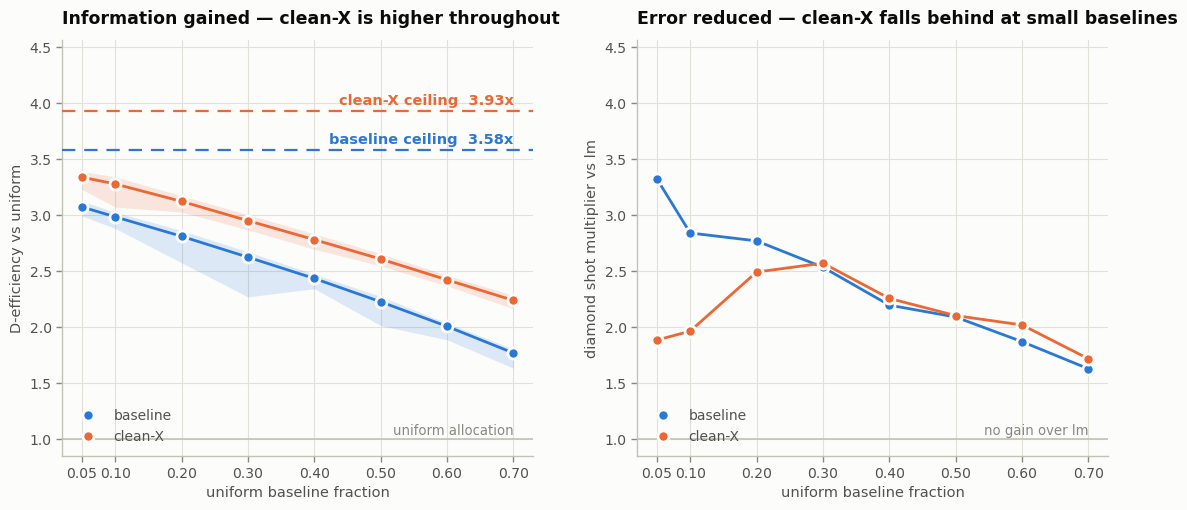

written: C:\Users\athar\Documents\Codex\ANL_SummerInternship\can-you-write-a-code-for\IBCDFO\GST_POUNDERS\seed_sweep_experiments\analytic_ceiling.png


In [6]:
import matplotlib.pyplot as plt

# Palette: slots 1-2 of the validated categorical set, assigned per device and held fixed.
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
COLOUR = {"baseline": "#2a78d6", "clean-X": "#eb6834"}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), facecolor=SURFACE)
fig.subplots_adjust(wspace=0.22)


def dress(ax, xlabel, ylabel, title):
    ax.set_facecolor(SURFACE)
    ax.grid(True, which="both", color=GRID, lw=0.8, ls="-", zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
        ax.spines[side].set_linewidth(1.0)
    ax.tick_params(colors=MUTED, labelcolor=INK2, length=4, width=1.0)
    ax.set_xlabel(xlabel, color=INK2, fontsize=10.5)
    ax.set_ylabel(ylabel, color=INK2, fontsize=10.5)
    ax.set_title(title, color=INK, fontsize=12.5, fontweight="semibold", loc="left", pad=12)


x = np.array(FRACS, dtype=float) / 100.0

# ---- left: D-efficiency, each device against its own ceiling ----------------------------
ax = axes[0]
top = max(d["ceiling"] for d in DEV.values())
for n, d in DEV.items():
    col = COLOUR[n]
    stat = np.array([[adaptive[(adaptive.device == n) &
                               (adaptive.arm == f"adaptive_D_nofpr_f{f:03d}")]["d_eff"].agg(s)
                      for s in ("mean", "min", "max")] for f in FRACS])
    ax.axhline(d["ceiling"], color=col, lw=1.6, ls=(0, (6, 4)), zorder=5)
    ax.text(x.max(), d["ceiling"] * 1.008, f"{n} ceiling  {d['ceiling']:.2f}x",
            ha="right", va="bottom", color=col, fontsize=10.5, fontweight="semibold", zorder=6)
    ax.fill_between(x, stat[:, 1], stat[:, 2], color=col, alpha=0.15, lw=0, zorder=2)
    ax.plot(x, stat[:, 0], color=col, lw=2.0, zorder=3)
    ax.plot(x, stat[:, 0], "o", ms=8, color=col, mec=SURFACE, mew=2.0, zorder=4, label=n)
ax.axhline(1.0, color=AXIS, lw=1.2, zorder=1)
ax.text(x.max(), 1.012, "uniform allocation", ha="right", va="bottom", color=MUTED, fontsize=9.5)
ax.set_ylim(0.85, top * 1.16)
dress(ax, "uniform baseline fraction", "D-efficiency vs uniform",
      "Information gained — clean-X is higher throughout")

# ---- right: diamond multiplier ----------------------------------------------------------
ax = axes[1]
for n in DEV:
    col = COLOUR[n]
    y = np.array([MULT[n].get(f"adaptive_D_nofpr_f{f:03d}", np.nan) for f in FRACS])
    ax.plot(x, y, color=col, lw=2.0, zorder=3)
    ax.plot(x, y, "o", ms=8, color=col, mec=SURFACE, mew=2.0, zorder=4, label=n)
ax.axhline(1.0, color=AXIS, lw=1.2, zorder=1)
ax.text(x.max(), 1.012, "no gain over lm", ha="right", va="bottom", color=MUTED, fontsize=9.5)
ax.set_ylim(0.85, top * 1.16)
dress(ax, "uniform baseline fraction", "diamond shot multiplier vs lm",
      "Error reduced — clean-X falls behind at small baselines")

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels([f"{v:.2f}" for v in x])
    ax.set_xlim(x.min() - 0.03, x.max() + 0.03)
    leg = ax.legend(frameon=False, fontsize=10, loc="lower left")
    for t in leg.get_texts():
        t.set_color(INK2)

fig.savefig(SSE / "analytic_ceiling.png", dpi=170, bbox_inches="tight", facecolor=SURFACE)
plt.show()
print(f"written: {SSE / 'analytic_ceiling.png'}")